In [3]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Churn_Modelling.csv")

In [5]:
X = df.iloc[:, 3:13]  # CreditScore to EstimatedSalary
y = df.iloc[:, 13]    # Exited

In [7]:
X['Gender'] = LabelEncoder().fit_transform(X['Gender'])
X = pd.get_dummies(X, columns=['Geography'], drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = Sequential([
    Dense(6, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# epoch = no of time moedel see training set

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6361 - loss: 0.6834 - val_accuracy: 0.8045 - val_loss: 0.5205
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7971 - loss: 0.5171 - val_accuracy: 0.8030 - val_loss: 0.4621
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7955 - loss: 0.4788 - val_accuracy: 0.8050 - val_loss: 0.4371
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8085 - loss: 0.4534 - val_accuracy: 0.8085 - val_loss: 0.4244
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8033 - loss: 0.4495 - val_accuracy: 0.8105 - val_loss: 0.4162
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8044 - loss: 0.4442 - val_accuracy: 0.8115 - val_loss: 0.4109
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8113 - loss: 0.4265 - val_accuracy: 0.8140 - val_loss: 0.4078
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7999 - loss: 0.4427 - val_accuracy: 0.

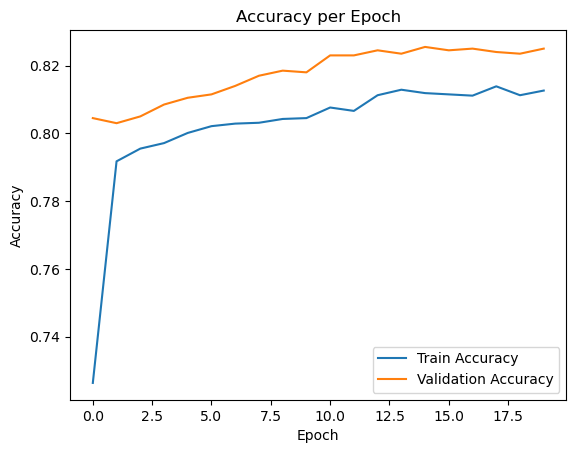

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [14]:
y_pred = (model.predict(X_test) > 0.5).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [15]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")
print("Confusion Matrix:\n", cm)

Final Accuracy: 82.50%
Confusion Matrix:
 [[1599    8]
 [ 342   51]]
